In [1]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_excel("Documents/project_purchase_pattern_analysis.xlsx")

In [4]:
df

,BillNo,Itemname,Quantity,Present_Date,Price,CustomerID,Country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...
49995,540646,CANDY SPOT CUSHION COVER,2,2011-01-10 14:32:00,3.36,NaN,United Kingdom
49996,540646,TOY TIDY PINK POLKADOT,1,2011-01-10 14:32:00,4.21,NaN,United Kingdom
49997,540646,MAGNETS PACK OF 4 RETRO PHOTO,2,2011-01-10 14:32:00,0.85,NaN,United Kingdom
49998,540646,BALLOON ART MAKE YOUR OWN FLOWERS,6,2011-01-10 14:32:00,1.66,NaN,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   BillNo        50000 non-null  int64         
 1   Itemname      49855 non-null  object        
 2   Quantity      50000 non-null  int64         
 3   Present_Date  50000 non-null  datetime64[ns]
 4   Price         50000 non-null  float64       
 5   CustomerID    31432 non-null  float64       
 6   Country       50000 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 2.7+ MB


In [6]:
df['CustomerID'] = df['CustomerID'].astype('object')
df['BillNo'] = df['BillNo'].astype('object')

In [13]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   BillNo        50000 non-null  object        
 1   Itemname      49855 non-null  object        
 2   Quantity      50000 non-null  int64         
 3   Present_Date  50000 non-null  datetime64[ns]
 4   Price         50000 non-null  float64       
 5   CustomerID    31432 non-null  object        
 6   Country       50000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 2.7+ MB


None

In [15]:
miss_df = pd.DataFrame(df.isnull().sum(), columns = ['Missing Values'])
miss_df.loc[:,'Proportion'] = round(df.isnull().sum()/df.shape[0] * 100, 3).astype('str') + '%' 
miss_df.loc[:,'Datatype']=df.dtypes
miss_df

,Missing Values,Proportion,Datatype
BillNo,0,0.0%,object
Itemname,145,0.29%,object
Quantity,0,0.0%,int64
Present_Date,0,0.0%,datetime64[ns]
Price,0,0.0%,float64
CustomerID,18568,37.136%,object
Country,0,0.0%,object


In [17]:
df= df.dropna(subset=['Itemname','CustomerID'])
df = df.dropna(axis=0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31432 entries, 0 to 49751
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   BillNo        31432 non-null  object        
 1   Itemname      31432 non-null  object        
 2   Quantity      31432 non-null  int64         
 3   Present_Date  31432 non-null  datetime64[ns]
 4   Price         31432 non-null  float64       
 5   CustomerID    31432 non-null  object        
 6   Country       31432 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 1.9+ MB


In [19]:
df.loc[:, 'Revenue'] = df['Quantity'] * df['Price']
df.head()

,BillNo,Itemname,Quantity,Present_Date,Price,CustomerID,Country,Revenue
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [21]:
df = df[df['Quantity']>0]

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31432 entries, 0 to 49751
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   BillNo        31432 non-null  object        
 1   Itemname      31432 non-null  object        
 2   Quantity      31432 non-null  int64         
 3   Present_Date  31432 non-null  datetime64[ns]
 4   Price         31432 non-null  float64       
 5   CustomerID    31432 non-null  object        
 6   Country       31432 non-null  object        
 7   Revenue       31432 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 2.2+ MB


In [25]:
df

,BillNo,Itemname,Quantity,Present_Date,Price,CustomerID,Country,Revenue
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...
49747,540645,HOME BUILDING BLOCK WORD,18,2011-01-10 14:20:00,5.45,14060.0,United Kingdom,98.10
49748,540645,TEA PARTY BIRTHDAY CARD,24,2011-01-10 14:20:00,0.42,14060.0,United Kingdom,10.08
49749,540645,"FANCY FONT BIRTHDAY CARD,",24,2011-01-10 14:20:00,0.42,14060.0,United Kingdom,10.08
49750,540645,CARD DOG AND BALL,24,2011-01-10 14:20:00,0.42,14060.0,United Kingdom,10.08


In [27]:
ret_date = df.groupby(by = df['Present_Date'].dt.date)[['Revenue']].sum()
ret_date

,Revenue
Present_Date,
2010-12-01,45821.11
2010-12-02,47294.03
2010-12-03,21893.86
2010-12-05,31771.60
2010-12-06,30033.14
2010-12-07,53795.31
2010-12-08,39248.82
2010-12-09,35641.32
2010-12-10,32494.23


In [29]:
# Keep only numeric columns for outlier removal
df_numeric = df.select_dtypes(include='number')

Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

# Filter out rows that contain outliers in any numeric column
mask = ~((df_numeric < (Q1 - 1.5 * IQR)) | (df_numeric > (Q3 + 1.5 * IQR))).any(axis=1)
df_filtered = df[mask]

In [31]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25595 entries, 0 to 49751
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   BillNo        25595 non-null  object        
 1   Itemname      25595 non-null  object        
 2   Quantity      25595 non-null  int64         
 3   Present_Date  25595 non-null  datetime64[ns]
 4   Price         25595 non-null  float64       
 5   CustomerID    25595 non-null  object        
 6   Country       25595 non-null  object        
 7   Revenue       25595 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 1.8+ MB


In [33]:
df_filtered.to_excel("Market_basket_analysis.xlsx", sheet_name = "Cleaned_data", index = False)

In [34]:
from matplotlib import pyplot as plt 
import seaborn as sns

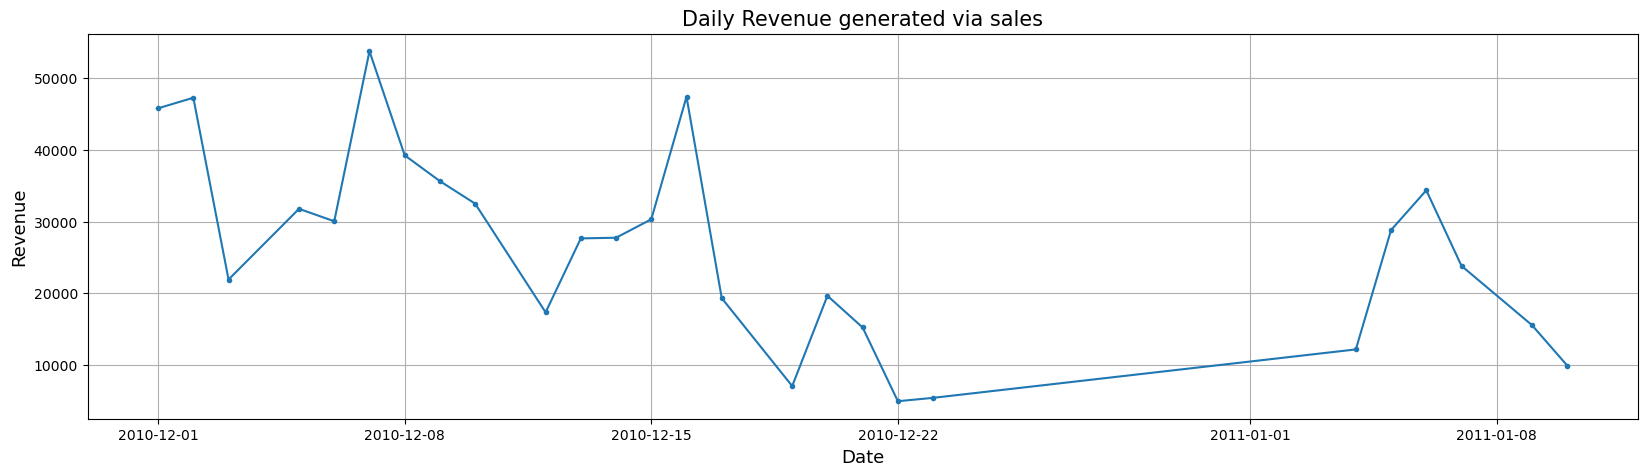

In [36]:
plt.figure(figsize=(20,5))
plt.plot(ret_date, ls ='-', marker ='.')
plt.title('Daily Revenue generated via sales', fontsize=15)
plt.xlabel('Date', fontsize= 13)
plt.ylabel('Revenue', fontsize= 13)
plt.grid();

In [93]:
ret_list = df_filtered.copy()
ret_list.loc[:,'Workday'] = ret_list.loc[:,'Present_Date'].dt.day_name()

In [95]:
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

In [97]:
ret_list['Workday'] = pd.Categorical(ret_list['Workday'], categories = day_order, ordered = True)
ret_list

,BillNo,Itemname,Quantity,Present_Date,Price,CustomerID,Country,Revenue,Workday
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,Wednesday
1,536365,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,Wednesday
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday
...,...,...,...,...,...,...,...,...,...
49746,540645,TRADITIONAL MODELLING CLAY,24,2011-01-10 14:20:00,1.25,14060.0,United Kingdom,30.00,Monday
49748,540645,TEA PARTY BIRTHDAY CARD,24,2011-01-10 14:20:00,0.42,14060.0,United Kingdom,10.08,Monday
49749,540645,"FANCY FONT BIRTHDAY CARD,",24,2011-01-10 14:20:00,0.42,14060.0,United Kingdom,10.08,Monday
49750,540645,CARD DOG AND BALL,24,2011-01-10 14:20:00,0.42,14060.0,United Kingdom,10.08,Monday


In [99]:
day_wise = pd.DataFrame(ret_list.groupby(ret_list['Workday'], observed= True)['Revenue'].mean().fillna(0))
day_wise

,Revenue
Workday,
Sunday,8.026780
Monday,11.390261
Tuesday,11.760020
Wednesday,11.556264
Thursday,11.963494
Friday,11.784221


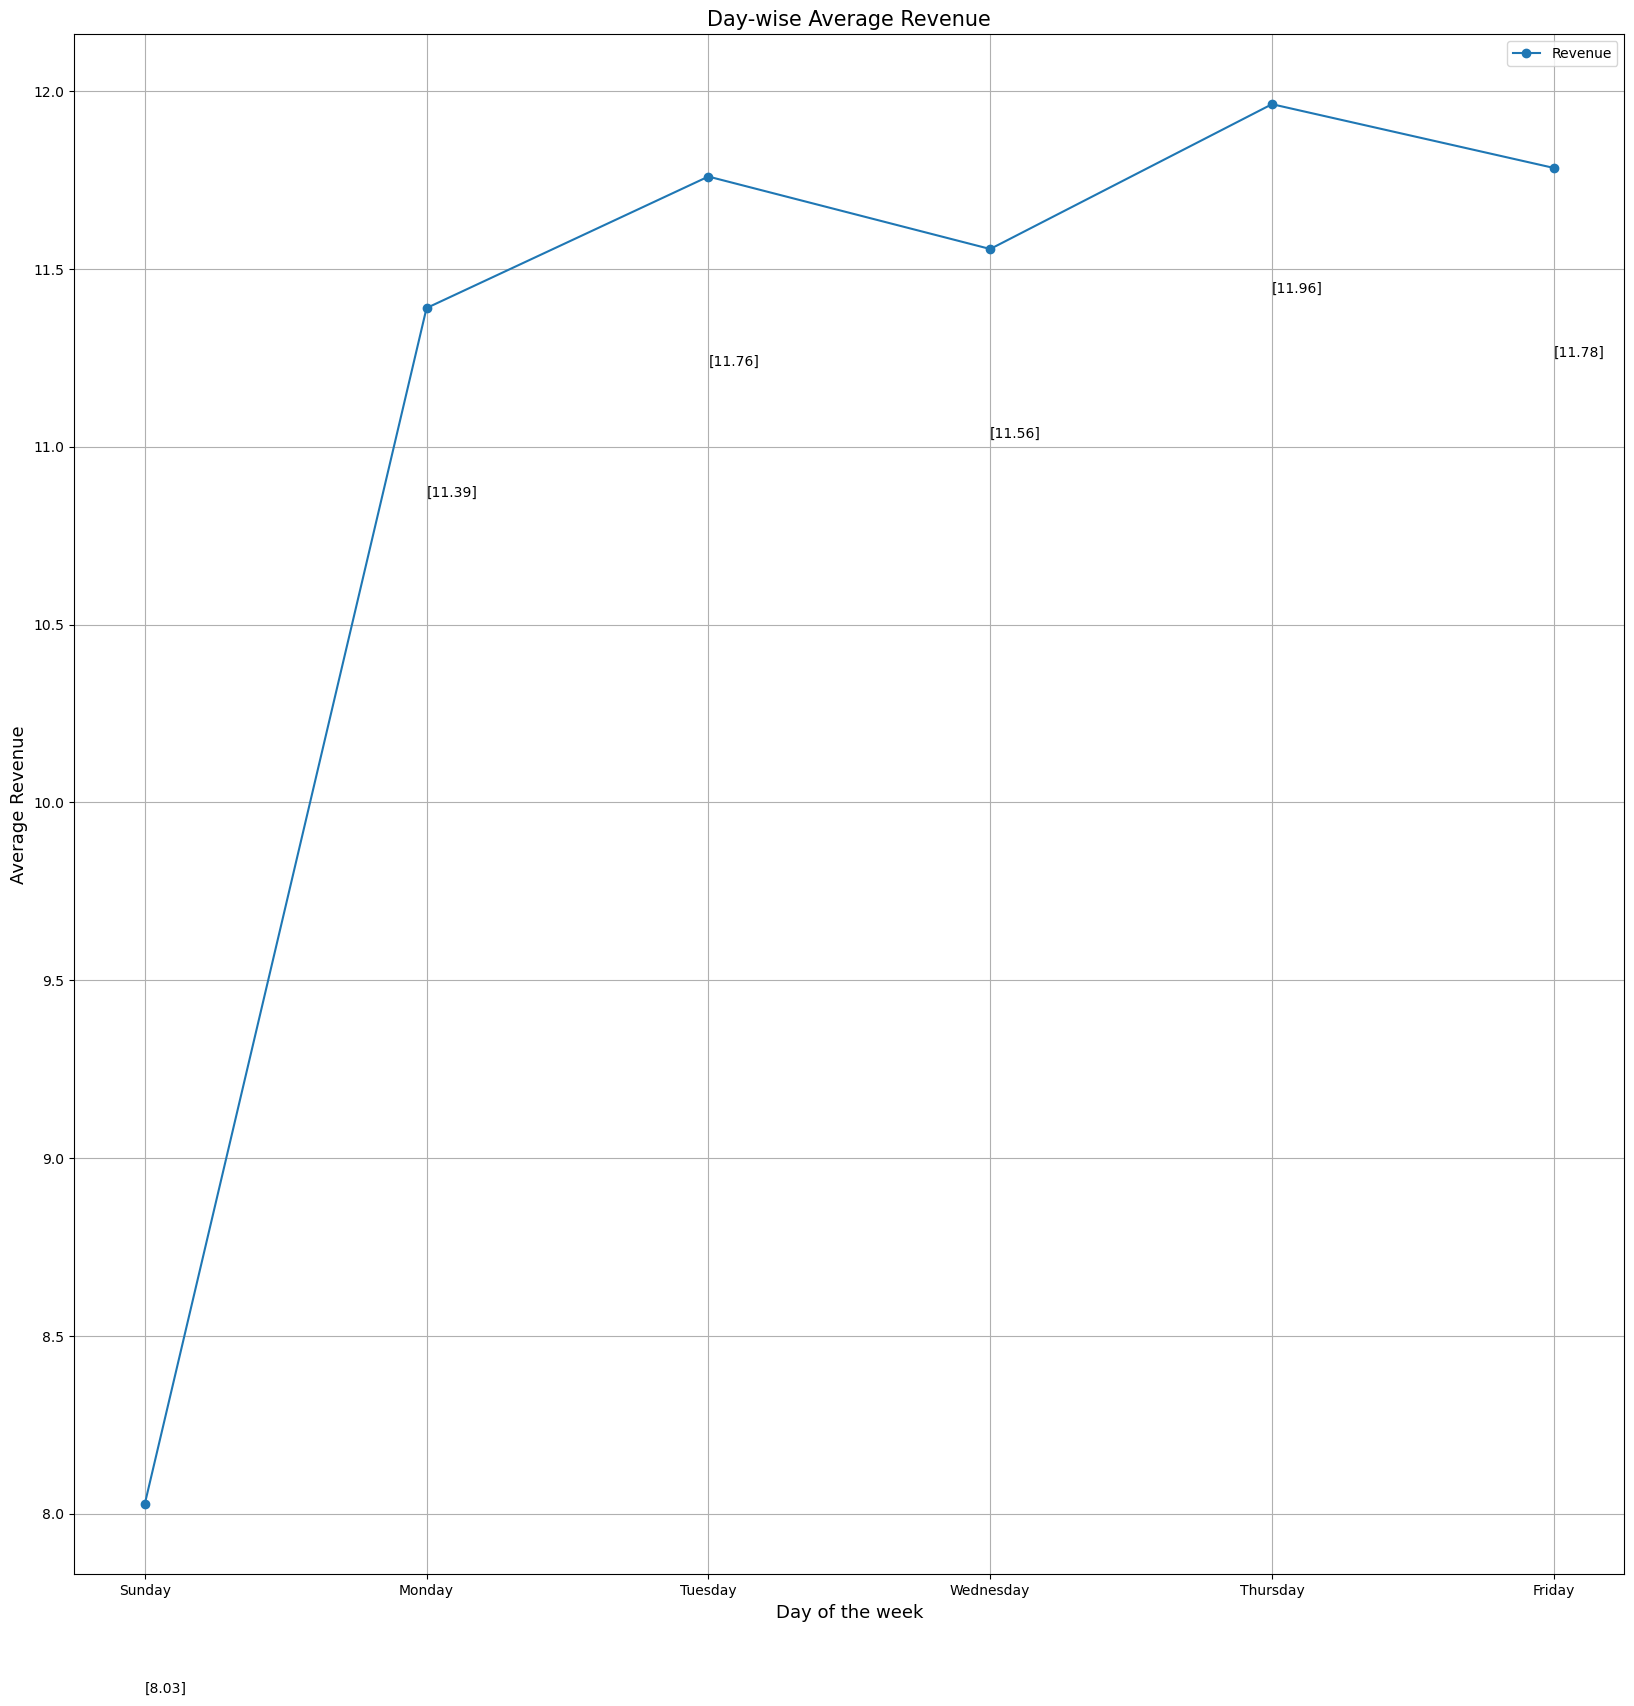

In [101]:
line = day_wise.plot(kind= 'line', ls= '-', marker='o', figsize=(20,20))
for x, y in enumerate(day_wise.values):
    line.text(x, y-0.5, str(np.round(y,2)), ha='left', va='top')
line.grid()
plt.xlabel('Day of the week', fontsize=13)
plt.ylabel('Average Revenue', fontsize=13)
plt.title('Day-wise Average Revenue', fontsize=15);
    

In [103]:
# TSA of total sales by BillNo
ret_cust = ret_list.groupby(by=['CustomerID'])[['Revenue']].sum().sort_values(by='Revenue', ascending=False)
ret_cust.head(10)

,Revenue
CustomerID,
17850.0,4411.16
13081.0,3567.51
12748.0,2746.14
12681.0,2525.23
14298.0,2327.12
12433.0,2236.04
12501.0,1866.66
15808.0,1776.52
13089.0,1751.14


In [105]:
# Grouping the product names by total revenue generated
rev = ret_list.groupby('Itemname')['Revenue'].sum().sort_values(ascending=False)
display(rev.head(20))
print()
# Grouping the product names by total quantity sold
qty = ret_list.groupby('Itemname')['Quantity'].sum().sort_values(ascending=False)
display(qty.head(20))

Itemname
WHITE HANGING HEART T-LIGHT HOLDER     3369.15
SCOTTIE DOG HOT WATER BOTTLE           1866.15
JAM MAKING SET PRINTED                 1822.65
HAND WARMER BABUSHKA DESIGN            1717.80
WOODEN FRAME ANTIQUE WHITE             1637.20
ASSORTED COLOUR BIRD ORNAMENT          1627.47
RETROSPOT HEART HOT WATER BOTTLE       1624.35
HOT WATER BOTTLE BABUSHKA              1614.20
CHOCOLATE HOT WATER BOTTLE             1598.85
HEART OF WICKER LARGE                  1595.95
HEART OF WICKER SMALL                  1526.25
PAPER CHAIN KIT 50'S CHRISTMAS         1519.25
JUMBO BAG RED RETROSPOT                1441.05
RED WOOLLY HOTTIE WHITE HEART.         1380.06
KNITTED UNION FLAG HOT WATER BOTTLE    1369.26
FAWN BLUE HOT WATER BOTTLE             1365.10
ALARM CLOCK BAKELIKE GREEN             1361.25
NATURAL SLATE HEART CHALKBOARD         1354.05
HOME BUILDING BLOCK WORD               1326.85
RED HANGING HEART T-LIGHT HOLDER       1274.40
Name: Revenue, dtype: float64

Itemname
JAM MAKING SET PRINTED                1257
HAND WARMER BABUSHKA DESIGN           1218
WHITE HANGING HEART T-LIGHT HOLDER    1157
PACK OF 72 RETROSPOT CAKE CASES       1040
ASSORTED COLOUR BIRD ORNAMENT          963
HEART OF WICKER SMALL                  925
HOMEMADE JAM SCENTED CANDLES           840
ANTIQUE SILVER TEA GLASS ETCHED        756
JUMBO BAG RED RETROSPOT                739
PACK OF 60 PINK PAISLEY CAKE CASES     703
60 TEATIME FAIRY CAKE CASES            702
SMALL POPCORN HOLDER                   694
60 CAKE CASES VINTAGE CHRISTMAS        643
VICTORIAN GLASS HANGING T-LIGHT        642
72 SWEETHEART FAIRY CAKE CASES         624
CLOTHES PEGS RETROSPOT PACK 24         587
LUNCH BAG RED RETROSPOT                578
STRAWBERRY CERAMIC TRINKET BOX         568
WOODEN FRAME ANTIQUE WHITE             568
SOLDIERS EGG CUP                       550
Name: Quantity, dtype: int64

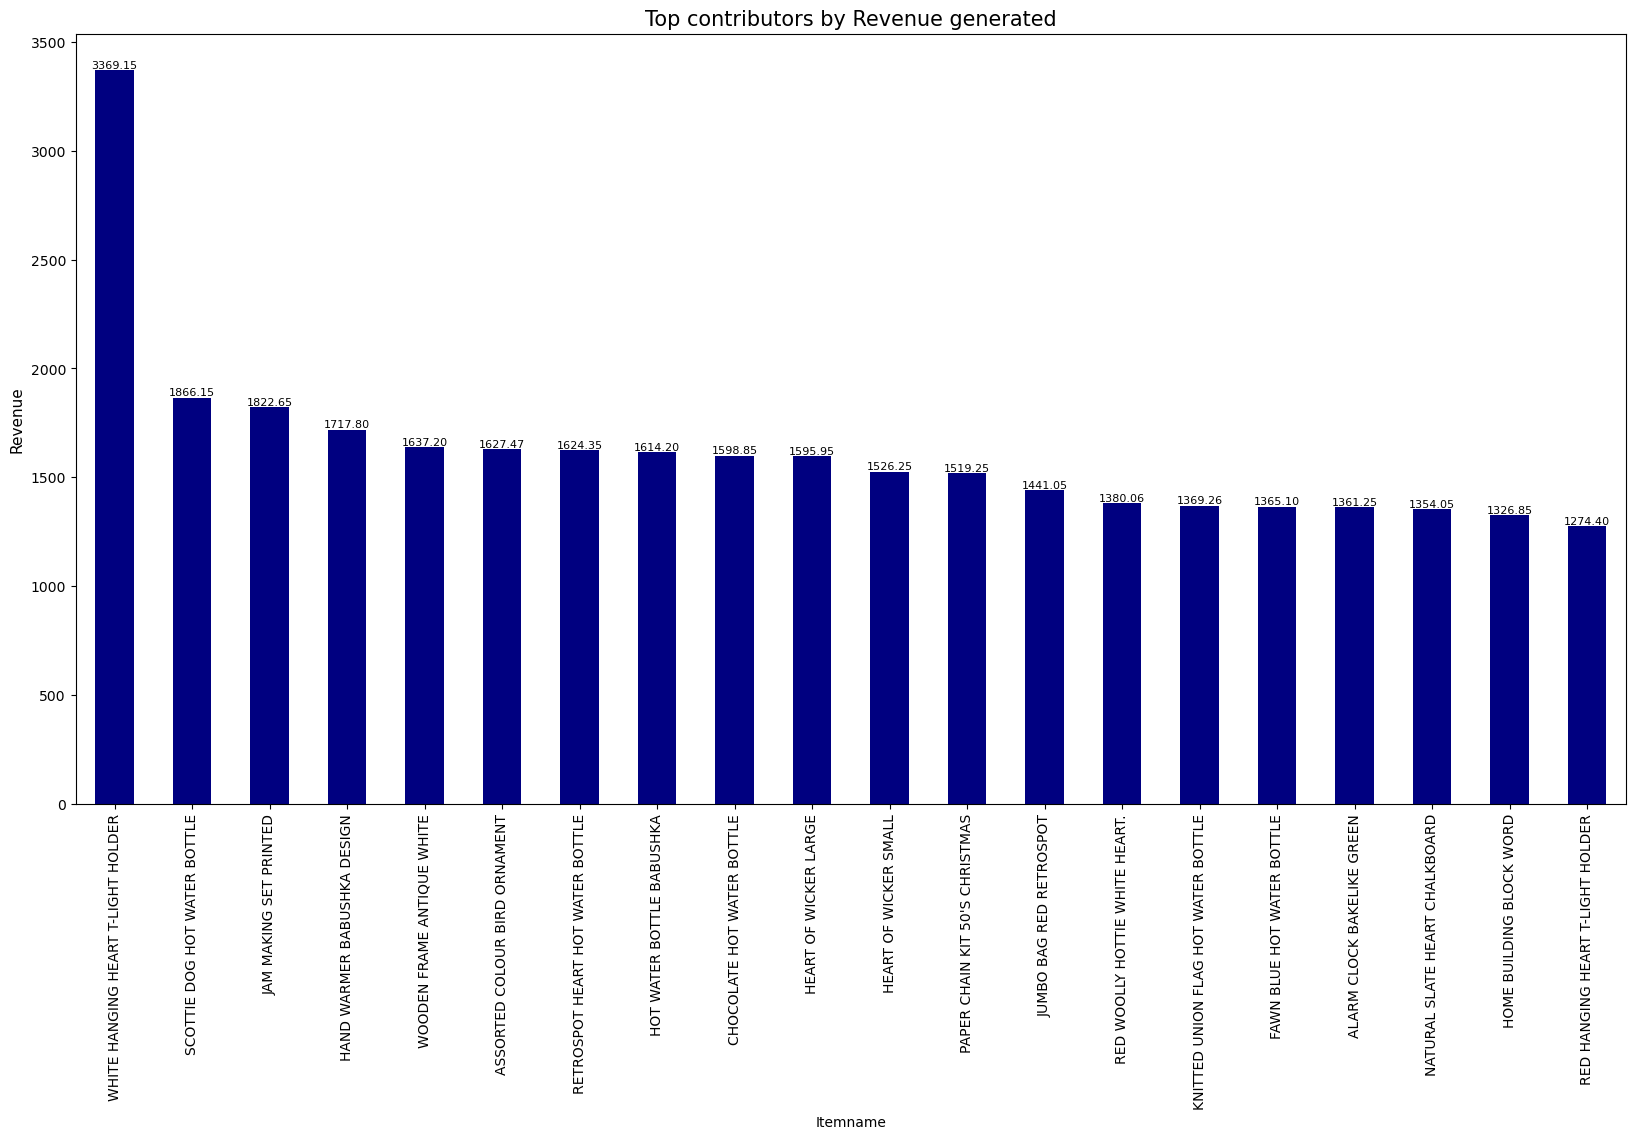

In [107]:
# Plotting the visualisation for Revenue
plt.figure(figsize=(20,10))
bar_rev = rev.head(20).plot(kind='bar', color='navy')
plt.title('Top contributors by Revenue generated', fontsize=15)
plt.ylabel('Revenue', fontsize=11);

for bar in bar_rev.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

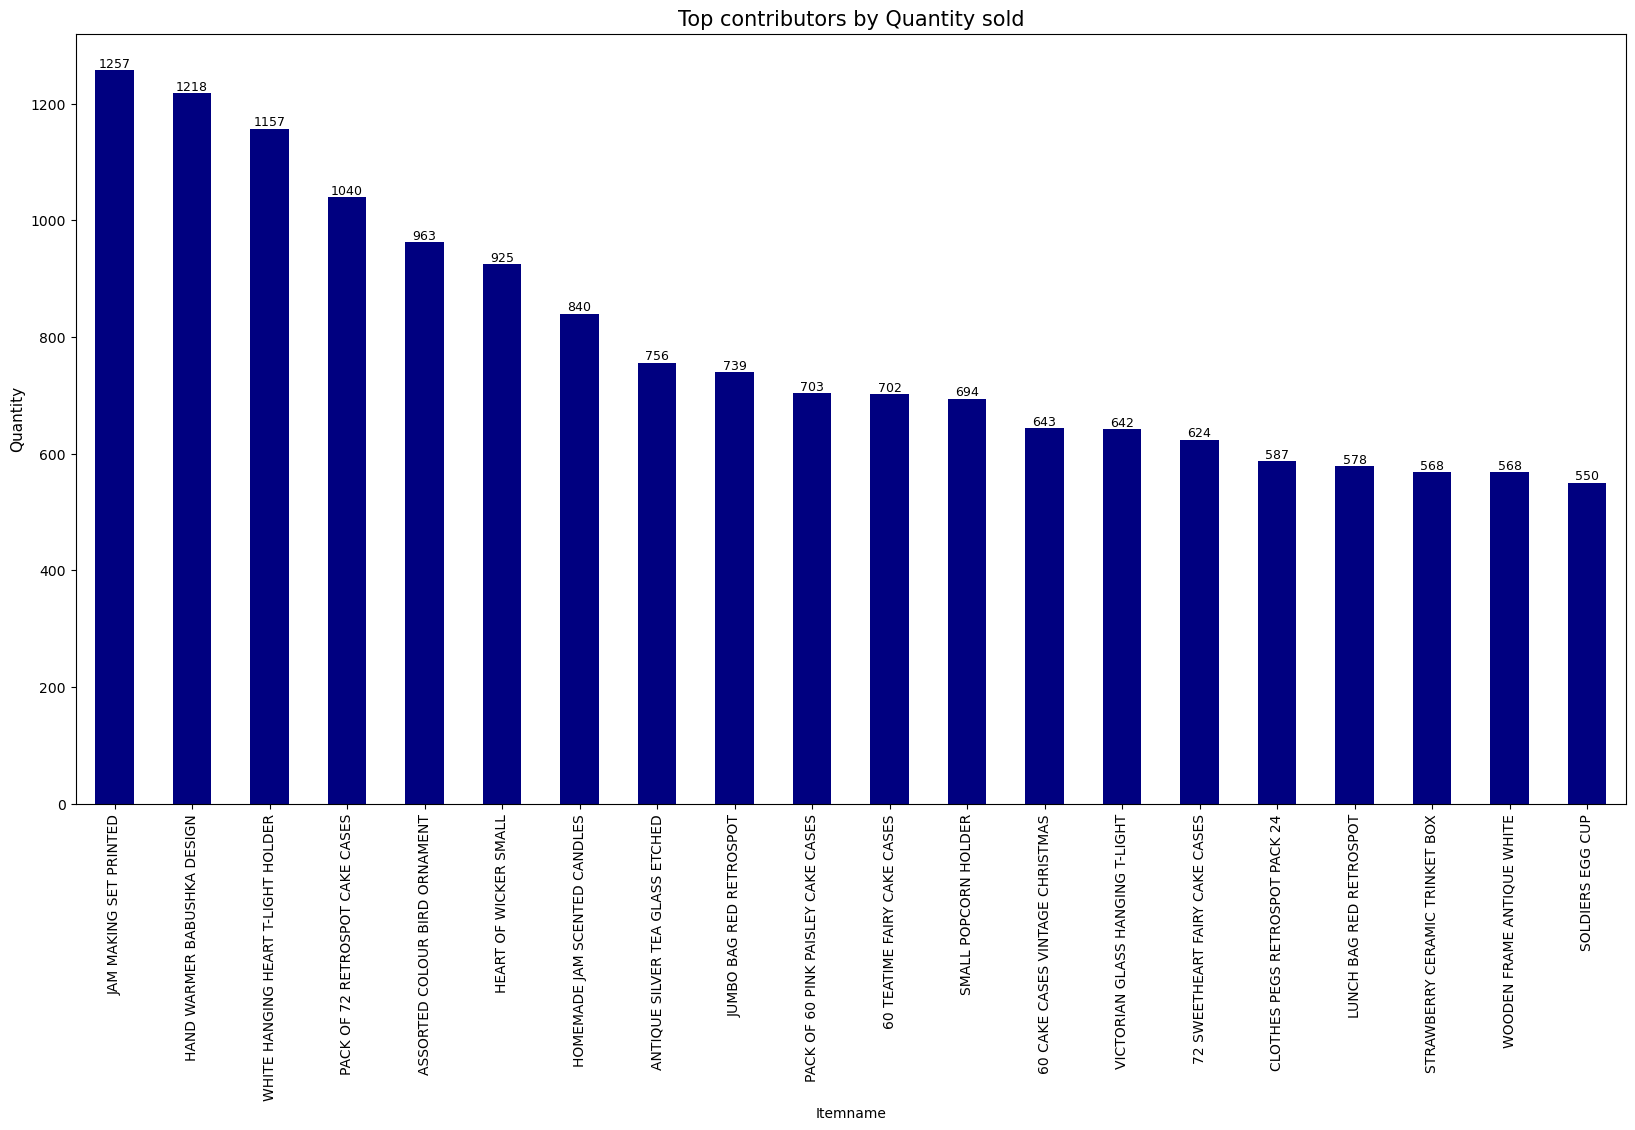

In [109]:
# Plotting the visualisation for Quantity
plt.figure(figsize=(20,10))
qty_rev = qty.head(20).plot(kind='bar', color='navy')
plt.title('Top contributors by Quantity sold', fontsize=15)
plt.ylabel('Quantity', fontsize=11);

for bar in qty_rev.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)

In [115]:
transaction = df.groupby(['BillNo', 'Present_Date'])['Itemname'].apply(lambda x: ', '.join(x)).reset_index()
transaction.head()

,BillNo,Present_Date,Itemname
0,536365,2010-12-01 08:26:00,"WHITE HANGING HEART T-LIGHT HOLDER, WHITE META..."
1,536366,2010-12-01 08:28:00,"HAND WARMER UNION JACK, HAND WARMER RED POLKA DOT"
2,536367,2010-12-01 08:34:00,"ASSORTED COLOUR BIRD ORNAMENT, POPPY'S PLAYHOU..."
3,536368,2010-12-01 08:34:00,"JAM MAKING SET WITH JARS, RED COAT RACK PARIS ..."
4,536369,2010-12-01 08:35:00,BATH BUILDING BLOCK WORD


In [117]:
transaction.drop(columns=['BillNo', 'Present_Date'], inplace=True)

In [113]:
transaction

,BillNo,Present_Date,Itemname
0,536365,2010-12-01 08:26:00,"WHITE HANGING HEART T-LIGHT HOLDER, WHITE META..."
1,536366,2010-12-01 08:28:00,"HAND WARMER UNION JACK, HAND WARMER RED POLKA DOT"
2,536367,2010-12-01 08:34:00,"ASSORTED COLOUR BIRD ORNAMENT, POPPY'S PLAYHOU..."
3,536368,2010-12-01 08:34:00,"JAM MAKING SET WITH JARS, RED COAT RACK PARIS ..."
4,536369,2010-12-01 08:35:00,BATH BUILDING BLOCK WORD
...,...,...,...
1624,540640,2011-01-10 12:36:00,"ENAMEL BREAD BIN CREAM, WOOD BLACK BOARD ANT W..."
1625,540641,2011-01-10 13:20:00,"SCOTTIE DOG HOT WATER BOTTLE, RED COAT RACK PA..."
1626,540642,2011-01-10 13:22:00,"BLACK LOVE BIRD CANDLE, HOME SWEET HOME MUG, R..."
1627,540644,2011-01-10 14:16:00,"PLASTERS IN TIN SKULLS, PLASTERS IN TIN WOODLA..."


In [119]:
items_df = transaction['Itemname'].str.split(',', expand=True)
items_df

,0,1,2,3,4,5,6,7,8,9,...,165,166,167,168,169,170,171,172,173,174
0,WHITE HANGING HEART T-LIGHT HOLDER,WHITE METAL LANTERN,CREAM CUPID HEARTS COAT HANGER,KNITTED UNION FLAG HOT WATER BOTTLE,RED WOOLLY HOTTIE WHITE HEART.,SET 7 BABUSHKA NESTING BOXES,GLASS STAR FROSTED T-LIGHT HOLDER,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,HAND WARMER UNION JACK,HAND WARMER RED POLKA DOT,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,ASSORTED COLOUR BIRD ORNAMENT,POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE KITCHEN,FELTCRAFT PRINCESS CHARLOTTE DOLL,IVORY KNITTED MUG COSY,BOX OF 6 ASSORTED COLOUR TEASPOONS,BOX OF VINTAGE JIGSAW BLOCKS,BOX OF VINTAGE ALPHABET BLOCKS,HOME BUILDING BLOCK WORD,LOVE BUILDING BLOCK WORD,...,None,None,None,None,None,None,None,None,None,None
3,JAM MAKING SET WITH JARS,RED COAT RACK PARIS FASHION,YELLOW COAT RACK PARIS FASHION,BLUE COAT RACK PARIS FASHION,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,BATH BUILDING BLOCK WORD,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1624,ENAMEL BREAD BIN CREAM,WOOD BLACK BOARD ANT WHITE FINISH,3 TIER CAKE TIN GREEN AND CREAM,ROUND CAKE TIN VINTAGE RED,VINTAGE CREAM CAT FOOD CONTAINER,OVEN MITT APPLES DESIGN,RED KITCHEN SCALES,CHILDRENS APRON APPLES DESIGN,HEART OF WICKER LARGE,BLACK AND WHITE DOG BOWL,...,None,None,None,None,None,None,None,None,None,None
1625,SCOTTIE DOG HOT WATER BOTTLE,RED COAT RACK PARIS FASHION,YELLOW COAT RACK PARIS FASHION,BLUE COAT RACK PARIS FASHION,DOORMAT TOPIARY,DOORMAT SPOTTY HOME SWEET HOME,ROUND CAKE TIN VINTAGE GREEN,HEART IVORY TRELLIS SMALL,HEART FILIGREE DOVE SMALL,WHITE BROCANTE SOAP DISH,...,None,None,None,None,None,None,None,None,None,None
1626,BLACK LOVE BIRD CANDLE,HOME SWEET HOME MUG,REGENCY CAKESTAND 3 TIER,SET3 BOOK BOX GREEN GINGHAM FLOWER,SET/3 RED GINGHAM ROSE STORAGE BOX,PLASTERS IN TIN STRONGMAN,JUMBO BAG SPACEBOY DESIGN,JUMBO BAG RED RETROSPOT,WATERING CAN PINK BUNNY,ROMANTIC PINKS RIBBONS,...,None,None,None,None,None,None,None,None,None,None
1627,PLASTERS IN TIN SKULLS,PLASTERS IN TIN WOODLAND ANIMALS,JUMBO BAG RED RETROSPOT,JUMBO BAG SPACEBOY DESIGN,JUMBO BAG WOODLAND ANIMALS,LUNCH BAG RED RETROSPOT,LUNCH BAG WOODLAND,LUNCH BAG CARS BLUE,PINK BLUE FELT CRAFT TRINKET BOX,PINK CREAM FELT CRAFT TRINKET BOX,...,None,None,None,None,None,None,None,None,None,None
